In [1]:
import sys

In [2]:
sys.path.insert(0,"..")

In [3]:
from src.preprocessing import load_and_preprocess

In [4]:
x_train_p, x_test_p, y_train, y_test, preprocessor, y_train_multi, y_test_multi = load_and_preprocess(
    "/home/sanjay/predictive-maintance/data/raw/ai4i2020.csv"
)

In [5]:
from sklearn.ensemble import RandomForestClassifier

In [6]:
rf=RandomForestClassifier(
n_estimators=200,
class_weight='balanced',
random_state=42
)
rf.fit(x_train_p,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [7]:
y_pred=rf.predict(x_test_p)

In [8]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))

[[1926    6]
 [  15   53]]


In [9]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.78      0.83        68

    accuracy                           0.99      2000
   macro avg       0.95      0.89      0.91      2000
weighted avg       0.99      0.99      0.99      2000



In [10]:
!pip install shap

In [11]:
import shap

In [12]:
explainer = shap.TreeExplainer(rf)


In [13]:
shap_values = explainer.shap_values(x_test_p)

In [14]:
type(shap_values)

numpy.ndarray

In [15]:
import numpy as np

print(np.array(shap_values).shape)

(2000, 8, 2)


In [16]:
feature_names = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Temp_diff [K]',
    'Mechanical Power [W]'
]

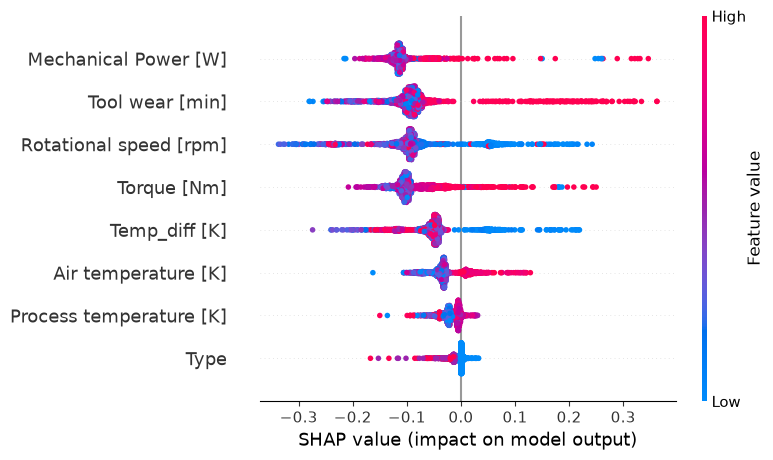

In [17]:
shap.summary_plot(
    shap_values[:, :, 1],
    x_test_p,
    feature_names=feature_names
)

## SHAP Explainability Conclusion

The SHAP summary plot shows that **Mechanical Power [W]**, **Tool wear [min]**, **Rotational speed [rpm]**, **Torque [Nm]**, and **Temp_diff [K]** have the highest overall influence on the Random Forest's failure predictions.

These features are consistent with the failure mechanisms identified during EDA and rule verification. Mechanical Power is directly related to the PWF rule, Temp_diff and Rotational speed are involved in the HDF rule, and Tool wear and Torque are important components of the OSF and TWF conditions. The `Type` feature also contributes to the OSF definition because the OSF threshold varies by machine type.

Air temperature [K] and Process temperature [K] have relatively lower SHAP importance compared with these features. Overall, the SHAP analysis provides evidence that the Random Forest is relying heavily on machine-condition features that are meaningful for the dataset's defined failure mechanisms.

In [18]:
(y_test.values == 1) & (y_pred == 1)

array([False, False, False, ..., False, False, False], shape=(2000,))

In [19]:
y_test.values == 1

array([False, False, False, ..., False, False, False], shape=(2000,))

In [20]:
y_pred == 1

array([False, False, False, ..., False, False, False], shape=(2000,))

In [21]:
failure_indices = np.where(
    (y_test.values == 1) & (y_pred == 1)
)[0][:3]

print(failure_indices)

[17 21 40]


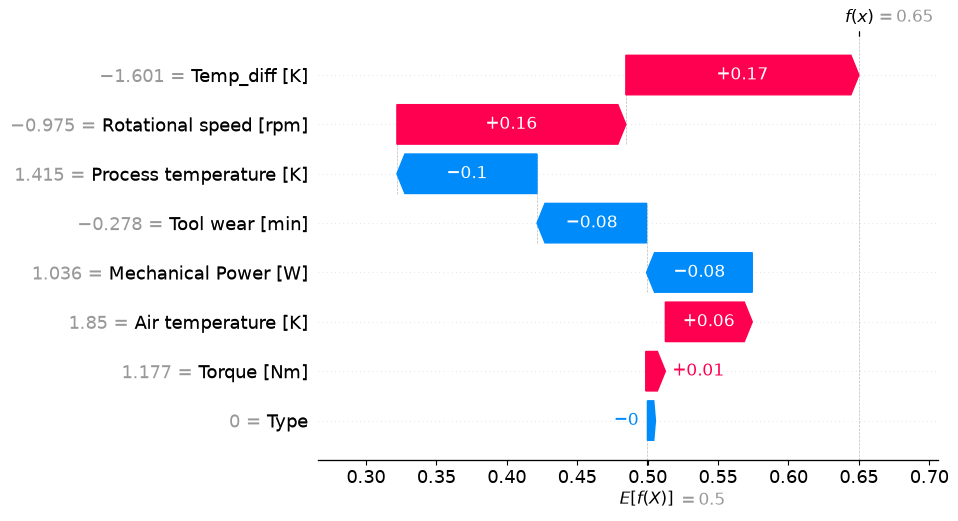

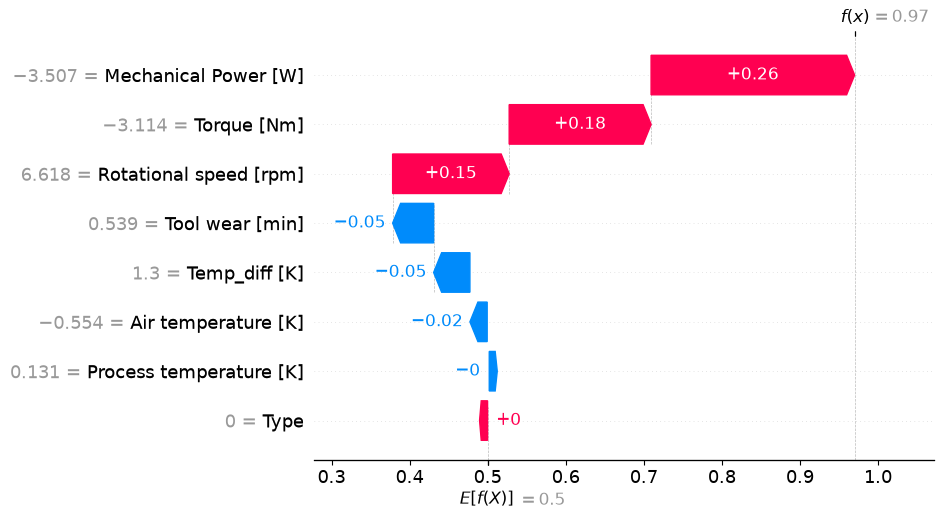

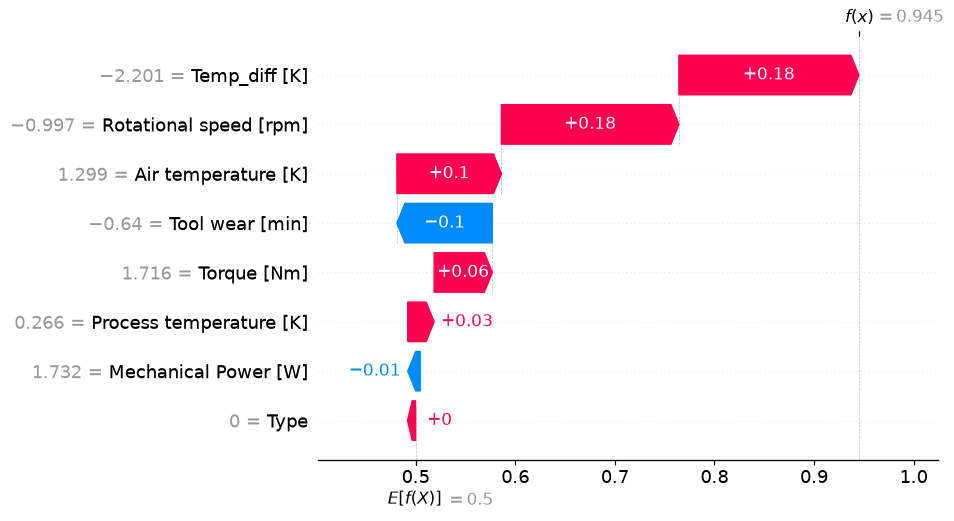

In [22]:
for i in failure_indices:
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[i, :, 1],
            base_values=explainer.expected_value[1],
            data=x_test_p[i],
            feature_names=feature_names
        )
    )

In [23]:
import joblib

joblib.dump(rf, '../models/model.pkl')
joblib.dump(preprocessor, '../models/preprocessor.pkl')

['../models/preprocessor.pkl']

In [24]:
import os

print(os.path.exists('../models/model.pkl'))
print(os.path.exists('../models/preprocessor.pkl'))

True
True


In [25]:
print(failure_indices)

[17 21 40]


In [26]:
for i in failure_indices:
    print(f"Index: {i}")
    print(x_test_p[i])
    print()

Index: 17
[ 0.          1.85031019  1.41545461 -0.97450011  1.17743612 -0.27803095
 -1.60094603  1.0359969 ]

Index: 21
[ 0.         -0.55363316  0.13109738  6.61785009 -3.11444392  0.53947594
  1.29965826 -3.50666724]

Index: 40
[ 0.          1.29940651  0.26629288 -0.99660303  1.7164164  -0.63962054
 -2.20107106  1.73240892]



Explaining index: 17


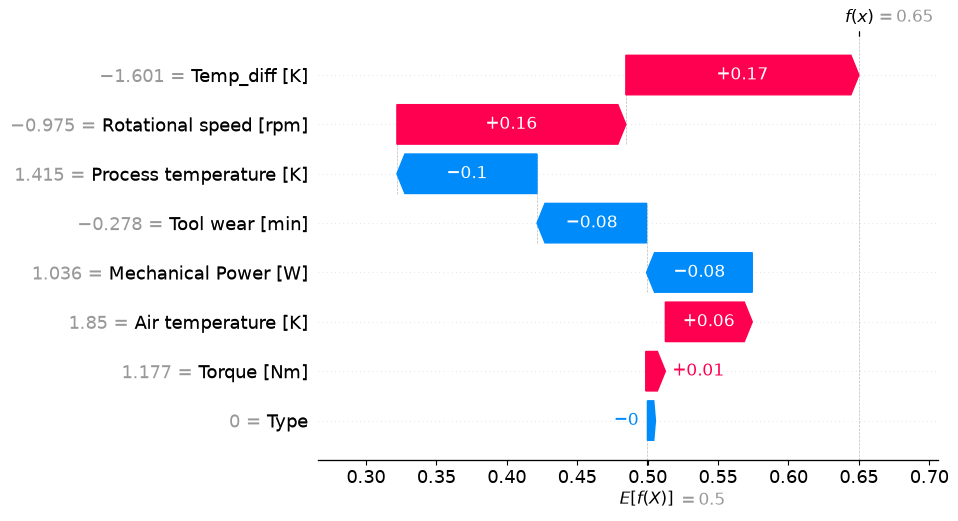

Explaining index: 21


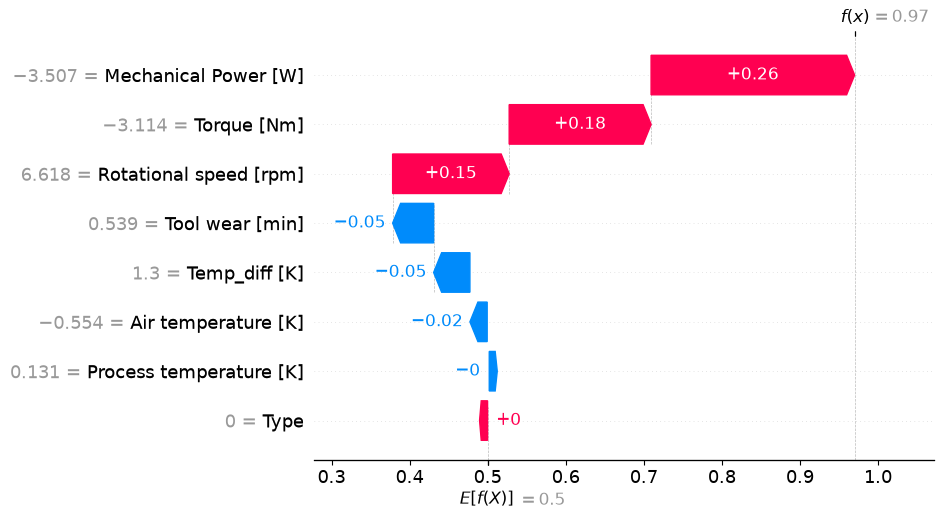

Explaining index: 40


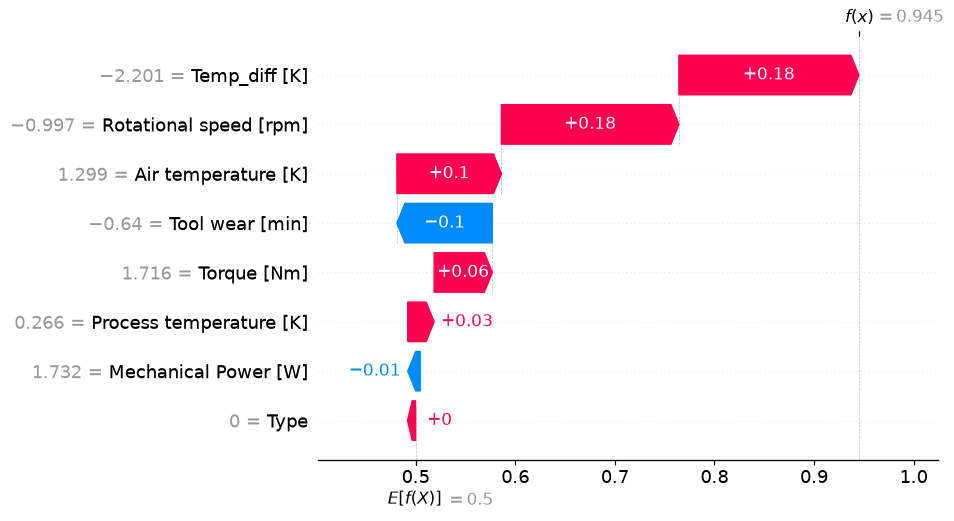

In [27]:
for i in failure_indices:
    print(f"Explaining index: {i}")

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[i, :, 1],
            base_values=explainer.expected_value[1],
            data=x_test_p[i],
            feature_names=feature_names
        )
    )